# Transfer Learning: MLIP → Critical Temperature

This notebook demonstrates advanced transfer learning using a pre-trained **Machine Learning Interatomic Potential (MLIP)** as the base model for predicting critical temperatures (Tc) of magnetic materials. This approach leverages the powerful atomic representations learned from large-scale materials datasets.

MLIPs are neural network models trained to predict **Energies**, **atomic forces**, and **stresses** from atomic structures across diverse chemical spaces.

## Prerequisites

- Complete the dataset preparation tutorial (Example 1) and copy `set_example_trainTL/` to this folder.
- Understanding of transfer learning concepts from previous example 3.

Let's begin by importing the necessary libraries:

In [2]:
import json
import os
import time

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from ase import Atoms
import yaml

from fairchem.core.common.tutorial_utils import fairchem_main

from fairchem.core.datasets import LmdbDataset
from sklearn.metrics import r2_score, mean_absolute_error

/home/enda/miniconda3/envs/MLFFopt_fairchem/lib/python3.9/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/enda/miniconda3/envs/MLFFopt_fairchem/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Utility Function: Result Collection and Analysis

This is the same helper function used in previous tutorials to collect and organize model predictions:

In [3]:
def collect_result(dft_path, prd_path, target, application=False):
    '''
    dft_path: input test set (lmdb format).
    prd_path: test prediction output, file name is ocp_predictions.npz 
    target  : target property name in lmdb
    application: Ture if the trained model is used for application.
                 False if it is used to collect output of test result.
    '''
    dft_raw = LmdbDataset({"src": dft_path})
    prd_raw = np.load(prd_path)
    # prd_raw.files

    if not application:
        dft = np.array([data[target] for data in dft_raw])
    
    # get ml result from output
    ids = [int(i.split('_')[1]) for i in prd_raw['ids']]
    inverse_ids = np.argsort(ids)
    prd = np.array([i[0] for i in prd_raw['energy']])
    prd = prd[inverse_ids]
    
    # create pandas dataframe
    dataset = LmdbDataset({"src": dft_path})
    data_list = []
    for ind, data in enumerate(dataset):
        # Customize keys depending on what's in each data sample
        row = {
            "id":     data.id,
            'UUID':   data.UUID,
            target + "_ML" : prd[ind],
        }
        if not application:
            row[target + "_DFT"] = dft[ind]
            # row[target + "_ML" ] = data[target]
            
        data_list.append(row)
    
    # Convert to DataFrame
    df = pd.DataFrame(data_list)
    
    return df

## 1. Configuration for MLIP Transfer Learning

The configuration file for this example is `config_Tc_MLIP_FTL7.yml`.  It is similar to config file used in example3. 

# 2. MLIP Transfer Learning Training

Now we'll train a critical temperature prediction model using the pre-trained MLIP as base model. This approach leverages the rich atomic representations learned from diverse structures.

#### Setup
Define the output directory, job_name, configuration file path, and log names.

In [3]:
run_dir = f"result_Tc"   

job_name='Tc_MLIP_FTL7'   

config    = f"./config_{job_name}.yml"
log_file  = f"log_train_{job_name}.txt"
warn_file = f"warn_train_{job_name}.txt"

#### Specify the Pre-trained MLIP Model

The model name is `esen_30m_oam.pt`.

Please download `esen_30m_oam.pt` from [here](https://huggingface.co/facebook/OMAT24/blob/main/esen_30m_oam.pt) and place it in this example folder before proceeding.

In [ ]:
# the base model for TL
basemodel = './esen_30m_oam.pt'

### Start Transfer Learning Training

In [5]:
t0 = time.time()
! CUDA_VISIBLE_DEVICES={2}  \
python {fairchem_main()} --mode train --config-yml {config}           \
                         --run-dir {run_dir}  --identifier {job_name} \
                         --print-every 50 \
                         --checkpoint {basemodel}  \
                         > {log_file} 2>  {warn_file}
print(f'Elapsed time = {time.time() - t0:1.1f} seconds')

Elapsed time = 1972.9 seconds


### Extract MLIP Transfer Learning Model Path

After training completes, locate the trained model (checkpoint) directory.

In [6]:
# Obtain output dir for later convenience.
# This dir contains trained model (checkpoint).  
cpline = !grep "checkpoint_dir:" {log_file}
cpdir  = cpline[0].split(':')[-1].strip()
print(cpdir)

result_Tc/checkpoints/2025-10-11-11-05-52-Tc_MLIP_FTL7


In [7]:
# copy config file to the ouput dir for future need.
! cp {config} {cpdir}'/config.yml'

# 3. Evaluate Performance

#### Collect test results

In [10]:
dft_path = "set_example_trainTL/test.lmdb" 
prd_path = cpdir.replace('checkpoints', 'results')  +'/ocp_predictions.npz'
print('Path to test set used for training: ', dft_path)
print('Path to test prediction by ML: ',      prd_path)

df = collect_result(dft_path, prd_path, target='Tc', application=False)
df.to_csv('./performance_test_MLIP.csv')


Path to test set used for training:  set_example_trainTL/test.lmdb
Path to test prediction by ML:  result_Tc/results/2025-10-11-11-05-52-Tc_MLIP_FTL7/ocp_predictions.npz


In [11]:
# the top 4 rows.
df.head(4)

,id,UUID,Tc_ML,Tc_DFT
0,104693,2abc4d30-11e6-45e4-9937-24be12f965a5,104.3125,0.0
1,19519,f3303db4-c9bb-4970-8b35-0e410932dd83,415.7500,540.6
2,16402,d7be146b-5da3-4875-9da6-319abce48ec6,24.1250,0.5
3,13358,261382e9-91ad-48cf-99e0-efc0b5d825b1,469.5000,749.8


### Performance Visualization

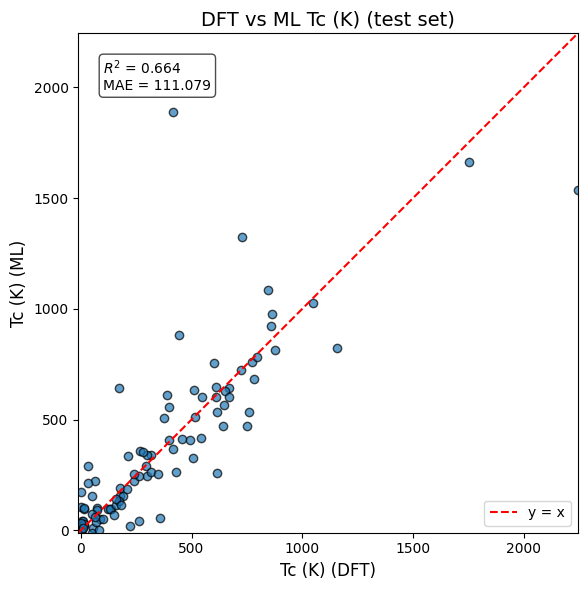

In [3]:
df = pd.read_csv('performance_test_MLIP.csv', index_col=0)
target = 'Tc'

# Compute metrics
r2 = r2_score(df[target+'_DFT'], df[target+'_ML'])
mae = mean_absolute_error(df[target+'_DFT'], df[target+'_ML'])

plt.figure(figsize=(6, 6))

# Scatter plot
plt.scatter(df[target+'_DFT'], df[target+'_ML'], alpha=0.7, edgecolor='k')

# 1:1 line
lims = [
    min(df[target+'_DFT'].min(), df[target+'_ML'].min()),
    max(df[target+'_DFT'].max(), df[target+'_ML'].max())
]
plt.plot(lims, lims, 'r--', label='y = x')

# Labels, title
plt.xlabel("Tc (K) (DFT)", fontsize=12)
plt.ylabel("Tc (K) (ML)", fontsize=12)
plt.title("DFT vs ML Tc (K) (test set)", fontsize=14)

# Same scale for x and y
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

# Add metrics as text inside plot
plt.text(0.05, 0.95, f"$R^2$ = {r2:.3f}\nMAE = {mae:.3f}",
         transform=plt.gca().transAxes,
         verticalalignment='top',
         bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

plt.legend()
plt.tight_layout()
plt.savefig('fig_performance_MLIP_FTL.png')
plt.show()


## Application

Applying the trained model to predict Tc for new compounds follows the same procedure as in Example 2; therefore, those steps are omitted here.